In [1]:
import sys
import os
import numpy as np
# Get the absolute path to the directory one level up (the project root)
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

In [2]:
from src.data_loader import load_mnist_multiclass
from src.utils import print_metrics

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = load_mnist_multiclass()
y_train

array([5, 4, 8, ..., 1, 0, 0], shape=(56000,))

In [5]:
print(X_train.shape)
print(y_train.shape)

(56000, 2025)
(56000,)


In [6]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [7]:
def compute_loss(y, y_hat):
    m = y.shape[0]
    log_likelihood = -np.log(y_hat[range(m), y])
    loss = np.sum(log_likelihood) / m
    return loss

In [8]:
def calculate_gradient(X, y, y_hat):
    m = y.size
    y_one_hot = np.eye(y_hat.shape[1])[y]
    return X.T @ (y_hat - y_one_hot) / m

In [9]:
num_iter=200
tolerance=1e-4
alpha=0.1

In [10]:
def fit(X, y, X_val=None, y_val=None):
    # stick a 1 column on for bias
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    theta = np.zeros((X_b.shape[1], 10))  # 10 classes for MNIST

    losses = []
    val_losses = []

    for i in range(num_iter):
        y_hat = softmax(X_b @ theta)
        loss = compute_loss(y, y_hat)
        losses.append(loss)
        actual_iter = i + 1

        # track validation loss too, helps spot overfitting
        if X_val is not None and y_val is not None:
            X_val_b = np.c_[np.ones((X_val.shape[0], 1)), X_val]
            y_val_hat = softmax(X_val_b @ theta)
            val_loss = compute_loss(y_val, y_val_hat)
            val_losses.append(val_loss)

        grad = calculate_gradient(X_b, y, y_hat)
        theta -= alpha * grad

        # stop if gradient gets flat enough
        if np.linalg.norm(grad) < tolerance:
            break
    return theta

In [11]:
def predict(theta, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        y_hat = softmax(X_b @ theta)
        return np.argmax(y_hat, axis=1)

In [11]:
theta = fit(X_train, y_train, X_val, y_val)
print(f"theta shape: {theta.shape}")
print(f"X_test shape: {X_test.shape}")


theta shape: (2026, 10)
X_test shape: (7000, 2025)


Train Accuracy: 0.9380
Train Precision (macro): 0.9380
Train Recall (macro): 0.9377
Train F1 Score (macro): 0.9377
Val Accuracy: 0.9316
Val Precision (macro): 0.9319
Val Recall (macro): 0.9318
Val F1 Score (macro): 0.9317
Test Accuracy: 0.9393
Test Precision (macro): 0.9393
Test Recall (macro): 0.9384
Test F1 Score (macro): 0.9388


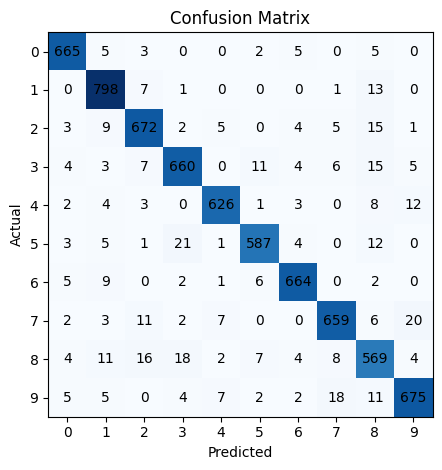

In [12]:
y_pred_train = predict(theta, X_train)
y_pred_val = predict(theta, X_val)

y_pred_test = predict(theta, X_test)
print_metrics(y_train, y_pred_train, y_val, y_pred_val, y_test, y_pred_test, model=None)

Train Accuracy: 0.9614
Train Precision (macro): 0.9612
Train Recall (macro): 0.9612
Train F1 Score (macro): 0.9612
Val Accuracy: 0.9573
Val Precision (macro): 0.9572
Val Recall (macro): 0.9573
Val F1 Score (macro): 0.9572
Test Accuracy: 0.9609
Test Precision (macro): 0.9606
Test Recall (macro): 0.9605
Test F1 Score (macro): 0.9605


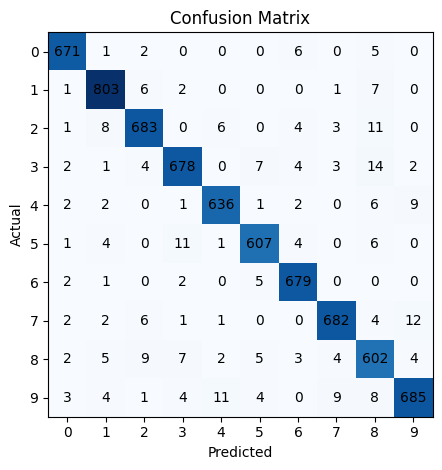

In [13]:
num_iter=2000
tolerance=1e-4
alpha=0.1
theta = fit(X_train, y_train, X_val, y_val)
y_pred_train = predict(theta, X_train)
y_pred_val = predict(theta, X_val)
y_pred_test = predict(theta, X_test)
print_metrics(y_train, y_pred_train, y_val, y_pred_val, y_test, y_pred_test, model=None)

Train Accuracy: 0.9784
Train Precision (macro): 0.9783
Train Recall (macro): 0.9783
Train F1 Score (macro): 0.9783
Val Accuracy: 0.9716
Val Precision (macro): 0.9714
Val Recall (macro): 0.9715
Val F1 Score (macro): 0.9714
Test Accuracy: 0.9733
Test Precision (macro): 0.9730
Test Recall (macro): 0.9730
Test F1 Score (macro): 0.9730


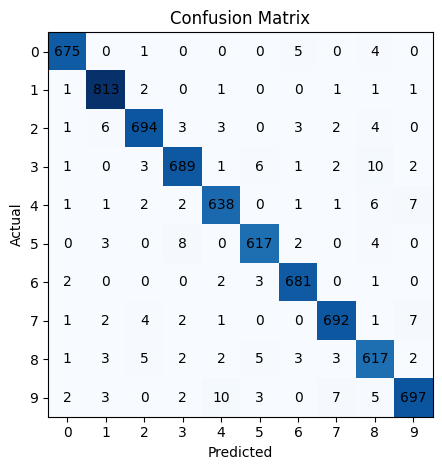

In [14]:
num_iter=2000
tolerance=1e-4
alpha=1
theta = fit(X_train, y_train, X_val, y_val)
y_pred_train = predict(theta, X_train)
y_pred_val = predict(theta, X_val)
y_pred_test = predict(theta, X_test)
print_metrics(y_train, y_pred_train, y_val, y_pred_val, y_test, y_pred_test, model=None)

Train Accuracy: 0.9810
Train Precision (macro): 0.9810
Train Recall (macro): 0.9809
Train F1 Score (macro): 0.9809
Val Accuracy: 0.9731
Val Precision (macro): 0.9730
Val Recall (macro): 0.9731
Val F1 Score (macro): 0.9731
Test Accuracy: 0.9744
Test Precision (macro): 0.9742
Test Recall (macro): 0.9742
Test F1 Score (macro): 0.9742


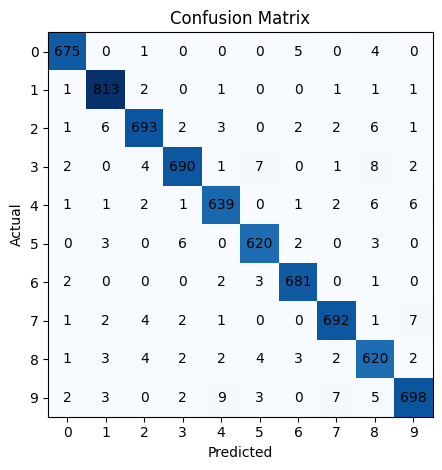

In [12]:
num_iter=3000
tolerance=1e-4
alpha=1
theta = fit(X_train, y_train, X_val, y_val)
y_pred_train = predict(theta, X_train)
y_pred_val = predict(theta, X_val)
y_pred_test = predict(theta, X_test)
print_metrics(y_train, y_pred_train, y_val, y_pred_val, y_test, y_pred_test, model=None)

In [13]:
from sklearn.metrics import accuracy_score
train_acc=accuracy_score(y_train,y_pred_train)
test_acc=accuracy_score(y_test,y_pred_test)

In [14]:
print(f"test acc{test_acc:.4f}")

test acc0.9744
